In [14]:
import matplotlib.pyplot as plt
import random
import itertools
from graph import (
    create_random_graph,
    MVC
)
random.seed(42)


In [15]:
def add_to_each(sets, element):
    copy_ = sets.copy()
    for s in copy_:
        s.append(element)
    return copy_

def power_set(lst):
    if lst == []:
        return [[]]
    return power_set(lst[1:]) + add_to_each(power_set(lst[1:]), lst[0])
    
def is_independent_set(G, S):
    """Return True if S is an independent set in G (no two nodes in S share an edge)."""
    S_set = set(S)
    for u in S_set:
        for v in G.adj[u]:
            if v in S_set:
                return False
    return True


def MIS(G):
    """Brute-force Maximum Independent Set via power set enumeration."""
    nodes = list(G.adj.keys())
    subsets = power_set(nodes)
    max_set = []
    for subset in subsets:
        if is_independent_set(G, subset) and len(subset) > len(max_set):
            max_set = subset
    return max_set

In [16]:
n_nodes  = 8
runs_mis = 300
edge_vals_mis = [1, 5, 10, 15, 20, 25, 28]

avg_sums = []

for m in edge_vals_mis:
    total = 0
    for _ in range(runs_mis):
        G = create_random_graph(n_nodes, m)
        total += len(MVC(G)) + len(MIS(G))
    avg_sums.append(total / runs_mis)

print("Edge counts :", edge_vals_mis)
print("|MIS|+|MVC| :", avg_sums)
print(f"All equal n={n_nodes}:", all(abs(s - n_nodes) < 1e-9 for s in avg_sums))

Edge counts : [1, 5, 10, 15, 20, 25, 28]
|MIS|+|MVC| : [8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0]
All equal n=8: True


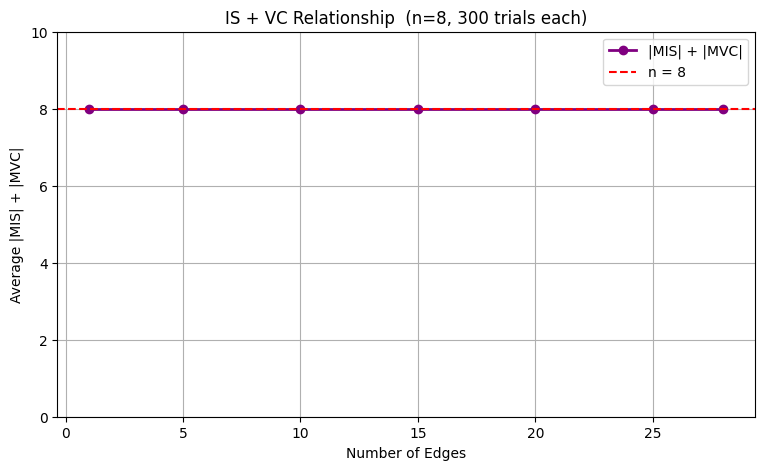

In [17]:
plt.figure(figsize=(9, 5))
plt.plot(edge_vals_mis, avg_sums, 'o-', color='purple', linewidth=2, label='|MIS| + |MVC|')
plt.axhline(y=n_nodes, color='red', linestyle='--', linewidth=1.5, label=f'n = {n_nodes}')
plt.xlabel('Number of Edges')
plt.ylabel('Average |MIS| + |MVC|')
plt.title(f'IS + VC Relationship  (n={n_nodes}, {runs_mis} trials each)')
plt.ylim(0, n_nodes + 2)
plt.legend()
plt.grid(True)
plt.savefig("mis_mvc_relationship.png", dpi=300)
plt.show()